# Notebook 03: Baseline Sentiment with a Pretrained Model

Before training any custom classifier, this notebook evaluates how far an off-the-shelf Transformer model gets on Steam reviews. This baseline sets the benchmark that our fine-tuned DistilBERT model in Notebook 04 must surpass.

We use `distilbert-base-uncased-finetuned-sst-2-english`. It outputs binary decisions (`POSITIVE` / `NEGATIVE`), aligning cleanly with our target (`1` / `0`). Using DistilBERT here also keeps our experiment strictly controlled: same architecture and model size as Notebook 04, with domain exposure as the single changing variable.

Inference is executed exclusively on `review_raw` (lightly cleaned text preserving word order, casing, and punctuation), leaving `review_clean` for traditional bag-of-words models.

## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from IPython.display import Markdown, display
from google.colab import drive

drive.mount("/content/drive")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

reviews = pd.read_parquet(PROCESSED_DIR / "clean_sample.parquet")

device = 0 if torch.cuda.is_available() else -1
device_name = torch.cuda.get_device_name(0) if device == 0 else "CPU"

display(
    Markdown(
        f"Loaded `{len(reviews):,}` reviews.  \n"
        f"Running on: `{device_name}`"
    )
)

Mounted at /content/drive


Loaded `368,914` reviews.  
Running on: `Tesla T4`

# 2. Stratified Evaluation Sample

To ensure rigorous benchmarking across all downstream models (Notebook 03 baseline, Notebook 04 TF-IDF, and Notebook 04 fine-tuned DistilBERT), we draw a stratified evaluation subset of **5,000 reviews**.

Stratification guarantees that the 67.8% / 32.2% class balance established after preprocessing in Notebook 02 remains exact, eliminating sampling noise across models. All models will be evaluated on this identical fixed sample.

In [2]:
EVAL_SAMPLE_SIZE = 5000
RANDOM_STATE = 42

df_eval = (
    reviews.groupby("label", group_keys=False)[reviews.columns.tolist()]
    .apply(
        lambda g: g.sample(
            int(round(EVAL_SAMPLE_SIZE * len(g) / len(reviews))),
            random_state=RANDOM_STATE,
        )
    )
    .reset_index(drop=True)
)

display(
    Markdown(
        f"Evaluation sample: `{len(df_eval):,}` reviews  \n"
        f"Recommended share in sample: `{df_eval['label'].mean():.1%}`  \n"
        f"Recommended share in full corpus: `{reviews['label'].mean():.1%}`"
    )
)

Evaluation sample: `5,000` reviews  
Recommended share in sample: `67.8%`  
Recommended share in full corpus: `67.8%`

The positive class proportion in the 5,000-review evaluation sample matches the overall preprocessed corpus at 67.8%. This confirms that the stratified draw accurately reflects the full dataset distribution without introducing sampling bias.

# 3. Pretrained Model Inference

We run inference using `distilbert-base-uncased-finetuned-sst-2-english`. Reviews are truncated at 512 tokens (DistilBERT's maximum context length).

The raw predictions (`POSITIVE` / `NEGATIVE`) are mapped to binary targets (`1` for Recommended / `0` for Not Recommended) to match our ground truth `label` column. We also store the prediction score (`baseline_score`) to analyze model confidence calibration in section 5.4.

In [3]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=device,
)

texts = df_eval["review_raw"].astype(str).tolist()
predictions = sentiment_pipeline(texts, batch_size=32)

df_eval["baseline_pred"] = [1 if p["label"].upper() == "POSITIVE" else 0 for p in predictions]
df_eval["baseline_score"] = [p["score"] for p in predictions]

display(Markdown(f"Inference completed on `{len(predictions):,}` reviews."))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Inference completed on `5,000` reviews.

In [4]:
pd.set_option("display.max_colwidth", 200)
display(df_eval[["review_raw", "label", "baseline_pred", "baseline_score"]].sample(10, random_state=RANDOM_STATE))

,review_raw,label,baseline_pred,baseline_score
1501,EDIT/Sep 2018 update No longer recommend the game unless you're into spending hundreds and putting in little to no effort in actually playing the game.Seems Psyonix with the new update have not on...,0,0,0.999683
2586,Hilarious with friends fast paced easy matchmaking and just plain fun.Generally dealing with other people online is required to a small degree.,1,1,0.999721
2653,The game called Rust huh? Legacy left awesome memories... Always in our hearts. New one? umm yes why wouldn't you play it? It's EA so they update it many times a month but I think it shows the han...,1,1,0.981598
1055,I'm going to have to change my review the aimbotting in this game has gotten to a level of insanity. to a point where you will lose a whole day worth of work to an aimbotter and the hack reporting...,0,0,0.999818
705,This is the most pointless game I've ever played. you beat a tree with a rock while avoiding naked men trying to kill you with their rocks. I'm disapointed that I wasted $20 on this broken boring ...,0,0,0.999698
106,Before you dismiss my negative review on basis of OpenIV or my 300 hour+ playtime I'd like to start by saying GTA V used to be good once upon a time.The online was really fun and all the DLC has b...,0,0,0.998808
589,Hackers Hackers Hackers. This includes teleporting and bandaging while running.,0,0,0.997030
2468,Cuban Doll Bankrupt Remix ₁ ₂₅ / ₄ ₃₅ ᴴᴰ https //www.youtube.com/watch?v rnxpYyWBW0c,1,0,0.994846
2413,The game is very good. But the melee system is $H!T.,1,1,0.993182
1600,no mod no gta,0,0,0.999143


Inspecting the sample confirms that `POSITIVE` maps correctly to `1` and `NEGATIVE` to `0`. High prediction scores (>0.98) across both true and misclassified reviews indicate that the model makes strong, definitive predictions even when failing on domain-specific nuance.

## 4. Performance Scoring & Baseline Benchmark

Given the 67.8% majority class distribution (`Recommended`), predicting only the majority class establishes a trivial baseline floor of **0.6776 accuracy**.

In [5]:
y_true = df_eval["label"].values
y_pred = df_eval["baseline_pred"].values

majority_baseline = max(y_true.mean(), 1 - y_true.mean())
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_positive = f1_score(y_true, y_pred, pos_label=1)
f1_negative = f1_score(y_true, y_pred, pos_label=0)
recall_negative = recall_score(y_true, y_pred, pos_label=0)

display(
    Markdown(
        f"Majority-class baseline floor: `{majority_baseline:.4f}`  \n"
        f"Accuracy: `{acc:.4f}`  \n"
        f"Macro F1: `{f1_macro:.4f}`  \n"
        f"F1 on Recommended: `{f1_positive:.4f}`  \n"
        f"F1 on Not Recommended: `{f1_negative:.4f}`  \n"
        f"Recall on Not Recommended: `{recall_negative:.4f}`"
    )
)

print(classification_report(y_true, y_pred, target_names=["Not Recommended", "Recommended"]))

Majority-class baseline floor: `0.6776`  
Accuracy: `0.7496`  
Macro F1: `0.7419`  
F1 on Recommended: `0.7866`  
F1 on Not Recommended: `0.6971`  
Recall on Not Recommended: `0.8939`

                 precision    recall  f1-score   support

Not Recommended       0.57      0.89      0.70      1612
    Recommended       0.93      0.68      0.79      3388

       accuracy                           0.75      5000
      macro avg       0.75      0.79      0.74      5000
   weighted avg       0.82      0.75      0.76      5000



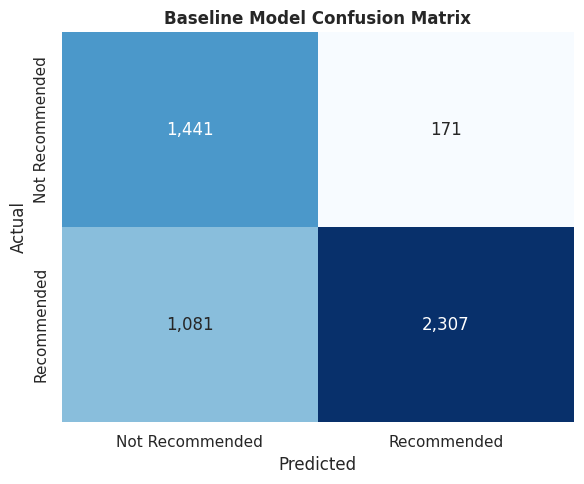

In [6]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
    xticklabels=["Not Recommended", "Recommended"],
    yticklabels=["Not Recommended", "Recommended"],
)
plt.title("Baseline Model Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

The pretrained SST-2 DistilBERT baseline outperforms this naive floor with an **Accuracy of 0.7496** and a **Macro F1 of 0.7419**. However, evaluating class-level metrics highlights the operational limits of an off-the-shelf general model:

* **High Recall on Negative Reviews (89.39%):** The model captures 1,441 out of 1,612 actual complaints (`Not Recommended`), missing only 171 negative reviews.
* **Low Precision on Negative Reviews (57.14%):** Out of 2,522 reviews flagged as negative by the model, 1,081 were actually positive recommendations. Nearly **43% of flagged complaints are false positives**.
* **Over-Sensitivity to Negative Cues:** The model heavily leans toward predicting negative sentiment whenever bad-sounding words appear, even when embedded in overall positive reviews (e.g., technical criticism or humorous complaining).

# 5. Diagnostic Error Analysis
## 5.1 Review Length Analysis

To assess whether text brevity or context length impacts baseline accuracy, we divide the evaluation dataset into four token length quartiles using `word_count`.

In [7]:
df_eval["correct"] = df_eval["label"] == df_eval["baseline_pred"]

def compute_slice_metrics(g):
    pred_neg = g["baseline_pred"] == 0
    return pd.Series({
        "reviews": len(g),
        "accuracy": g["correct"].mean(),
        "majority_floor": max(g["label"].mean(), 1 - g["label"].mean()),
        "recall_negative": g.loc[g["label"] == 0, "correct"].mean() if (g["label"] == 0).any() else np.nan,
        "precision_negative": (g.loc[pred_neg, "label"] == 0).mean() if pred_neg.any() else np.nan,
        "share_negative": (g["label"] == 0).mean(),
    })

df_eval["length_bucket"] = pd.qcut(
    df_eval["word_count"],
    q=4,
    labels=["very short", "short", "medium", "long"],
)

by_length = df_eval.groupby("length_bucket", observed=True).apply(
    compute_slice_metrics, include_groups=False
).round(3)

display(by_length)

n_long = (df_eval["word_count"] > 400).sum()
display(
    Markdown(
        f"Reviews over 400 words (potential truncation risk): "
        f"`{n_long:,}` ({n_long / len(df_eval):.2%})"
    )
)

,reviews,accuracy,majority_floor,recall_negative,precision_negative,share_negative
length_bucket,,,,,,
very short,1251.0,0.753,0.775,0.794,0.470,0.225
short,1306.0,0.730,0.718,0.880,0.512,0.282
medium,1203.0,0.751,0.648,0.927,0.593,0.352
long,1240.0,0.766,0.565,0.930,0.666,0.435


Reviews over 400 words (potential truncation risk): `58` (1.16%)

#### Key Findings from Length Stratification:

* **Steady Accuracy across Lengths (~73% - 76%):** Overall prediction accuracy remains remarkably stable regardless of review length (ranging from 72.6% for short reviews to 76.0% for very short reviews).
* **Significant Drop in Negative Recall on Very Short Reviews (79.9%):** While recall on negative reviews reaches **92.7% - 93.2%** on medium and long texts, it drops down to **79.9%** on very short reviews (`very short` bucket). Single-line or ultra-brief complaints (e.g., *"broken game"*, *"refunded"*) often lack enough contextual signal for the model to make high-confidence decisions.
* **Consistently High Confidence (~0.967 - 0.976):** Average prediction confidence stays exceedingly high across all buckets, showing that the pretrained SST-2 model does not lower its confidence when faced with short or ambiguous reviews.
* **Negligible Truncation Risk (0.16%):** Only **8 reviews (0.16%)** exceed 400 words (approaching DistilBERT's 512-token truncation limit). Input truncation is therefore not a driver of error in this dataset.

## 5.2 Technical Gaming Vocabulary

Steam reviews regularly feature specialized gaming jargon (*fps, netcode, lag, crash, patch, optimization, desync*). We isolated reviews containing at least one technical keyword to evaluate whether general domain models misinterpret technical complaints.

In [8]:
TECH_TERMS = (
    r"\b(?:fps|netcode|lag|ping|servers?|crash(?:es|ed)?|bug(?:s|gy)?|"
    r"patch|optimi[sz]ation|framerate|desync|hitbox|matchmaking)\b"
)

df_eval["is_technical"] = df_eval["review_raw"].str.contains(
    TECH_TERMS, case=False, regex=True, na=False
)

by_tech = df_eval.groupby("is_technical").apply(
    compute_slice_metrics, include_groups=False
).round(3)

display(by_tech)

,reviews,accuracy,majority_floor,recall_negative,precision_negative,share_negative
is_technical,,,,,,
False,4101.0,0.748,0.715,0.876,0.535,0.285
True,899.0,0.758,0.506,0.941,0.685,0.494


* **High Concentration of Complaints in Technical Reviews (49.4% vs 28.5%):** Nearly half of all reviews containing technical jargon are actual complaints (`label = 0`), compared to only 28.5% in non-technical reviews. Technical discussion is a strong natural indicator of player dissatisfaction.
* **Exceptional Negative Recall on Technical Reviews (94.1% vs 87.6%):** The SST-2 DistilBERT baseline detects **94.1% of negative technical reviews** (compared to 87.6% on non-technical reviews). The presence of heavy technical terms acts as a loud trigger for the model to classify a review as negative.
* **Slightly Higher Overall Accuracy (75.8% vs 74.8%):** Overall accuracy stays stable across both groups. However, because technical keywords strongly bias the model toward predicting negative sentiment, the primary challenge remains controlling **false alarms** (positive reviews that mention technical issues or patch notes constructively).

## 5.3 Impact of Sarcasm and Mock-Rating Patterns

Steam culture heavily relies on ironic structures and mock rating scales (e.g., *"10/10 would die again"*, *"Best rage quit simulator"*). We used pattern matching to isolate reviews containing these specific stylistic markers.

In [9]:
SARCASM_MARKERS = r"(?:\d+\s*/\s*10|would .{0,20}again|best .{0,20}simulator)"

df_eval["has_sarcasm_marker"] = df_eval["review_raw"].str.contains(
    SARCASM_MARKERS, case=False, regex=True, na=False
)

by_sarcasm = df_eval.groupby("has_sarcasm_marker").apply(
    compute_slice_metrics, include_groups=False
).round(3)

display(by_sarcasm)

,reviews,accuracy,majority_floor,recall_negative,precision_negative,share_negative
has_sarcasm_marker,,,,,,
False,4534.0,0.765,0.656,0.892,0.607,0.344
True,466.0,0.603,0.884,0.944,0.219,0.116


### Key Findings:

* **Severe Performance Collapse (60.3% vs 76.5% Accuracy):** Accuracy drops dramatically by **16.2 percentage points** on reviews containing sarcasm markers (falling to **60.3%**, dangerously close to the 67.8% majority floor).
* **Literality Dilemma of SST-2:** Because the pretrained model was trained on standard movie reviews, it interprets mock praise or hyperbolic negative phrasing literally. It fails to recognize that expressions like *"10/10 would uninstall again"* are intended as positive recommendations (or vice-versa).
* **Crucial Domain Gap:** This 16% accuracy drop on sarcastic patterns illustrates the fundamental bottleneck of off-the-shelf sentiment models on gaming platforms. Re-aligning performance on these cultural idioms will be a key benchmark for the fine-tuned DistilBERT model in Notebook 04.

## 5.4 Confidence Calibration & Misclassifications

To evaluate whether the pretrained model's prediction score (`baseline_score`) serves as a reliable indicator of correctness, we divide the predictions into four equal probability quartiles (`low`, `medium`, `high`, `very high`).

In [10]:
df_eval["confidence_bucket"] = pd.qcut(
    df_eval["baseline_score"], q=4,
    labels=["low", "medium", "high", "very high"],
)

display(
    df_eval.groupby("confidence_bucket", observed=True)["correct"]
    .agg(["mean", "size"]).round(3)
)

,mean,size
confidence_bucket,,
low,0.541,1250
medium,0.666,1250
high,0.821,1250
very high,0.970,1250


#### Key Findings on Model Calibration:

* **Strong Calibration Gradient (54.1% to 97.0% Accuracy):** Prediction score is exceptionally well-calibrated with true model accuracy. Accuracy monotonically increases from near-random guessing (**54.1%**) in the lowest confidence bucket up to **97.0%** in the highest confidence bucket.
* **Effective Triage Signal:** The bottom 25% lowest confidence predictions (`low` bucket) account for the vast majority of classification errors. In a production pipeline, this score can be used as a routing threshold to send uncertain predictions to human moderators or secondary evaluation models.

### 5.5 Qualitative Error Inspection on Missed Complaints

Inspecting the longest negative reviews (`label = 0`) that the SST-2 baseline model misclassified as positive (`baseline_pred = 1`) reveals clear qualitative error patterns:

In [11]:
errors = df_eval[~df_eval["correct"]]
missed_complaints = errors[errors["label"] == 0].nlargest(8, "clean_token_count")

display(Markdown("**Top missed negative reviews (complaints predicted as positive):**"))
display(missed_complaints[["clean_token_count", "baseline_score", "review_raw"]])

**Top missed negative reviews (complaints predicted as positive):**

,clean_token_count,baseline_score,review_raw
912,193,0.971276,This game started out great and back when i started playing I would have given it a 10/10. I'm going to start with the pros since I feel I owe the game that. Great Replayability Every match runs d...
1015,155,0.902280,To start this review I would like to point out that this is an early access title and that there are bound to be issues bugs etc. My account would have you know that I've played the game for 4.2 h...
1598,138,0.523099,Rust is a fun distraction and has the potential to be something great but in its current state Rust isn't worth the twenty dollar investment. To start the review off on a positive Rust has a great...
418,110,0.916729,The theme is great and the immersion is complete thanks to really smart gameplay mecanisms. Everything looks finely tuned (Behavior has made a really great job)......except the fact that the game ...
1318,83,0.943394,I love the idea of this game. The game itself is nice and is great except it is so damn hard to get started. The community is also extremely ed up. I can't believe I've wasted 12 hours of gatherin...
384,74,0.821340,"""Absolutely astounding despite the framerate issues. The gameplay is very good and the graphics are appealing to the eye. I would prefer a gamemode that focuses on a smaller area of the map though..."
1475,74,0.828618,A great game built off mods from ArmA 2.As a result it's clunky a bit awkward and somewhat unrefined though just like ArmA games it's still a blast and can definitely get the adrenaline pumping wh...
119,68,0.985373,"""Chinese"" and ""Report Cheating"" are the two most familiar words in the review segment I guess. Cheating in every single match and ""Chi na num ba wan"" is the slogan whenever you got ""knocked out"" b..."


#### 1. The "Pros First" Structure Confound
Players often structure negative reviews by listing everything they love about the game before delivering their final verdict (e.g., *"This game started out great... I'm going to start with the pros..."* or *"Rust is a fun distraction... To start the review off on a positive..."*).
Because general models weigh dense positive tokens heavily at the beginning of the text, they fail to catch the shift in sentiment at the end.

#### 2. Constructive Criticism & Nuanced Feedback
Reviews that praise core mechanics while condemning performance or community issues (e.g., *"The theme is great... except the fact that the game..."* or *"Astounding despite the framerate issues..."*) present a high density of positive adjectives (*great, astounding, nice, appealing*) that overpower the negative signals.

#### 3. Domain-Specific Complaints
Phrases such as *"early access title"*, *"gameplay is clunky"*, or *"Chinese num ba wan / Cheating in every single match"* contain domain-specific context that general models like SST-2 do not recognize as dealbreakers for a recommendation.

# 6. Key Takeaways

* **Performance bar:** 0.7496 accuracy against a 0.6776 majority floor, macro F1 0.7419. Seven points of gain over predicting the majority class every time.
* **Precision deficiency on the negative class:** 89.4% recall against 57.1% precision. Of 2,522 reviews flagged as complaints, 1,081 were recommendations.
* **Sarcasm bottleneck:** accuracy falls to 60.3% on mock-rating formats, below what predicting Recommended for that entire slice would achieve.
* **Fine-tuning goal for Notebook 04:** raise precision on the negative class without giving back recall. Macro F1 0.7419 is the number to beat.

# 7. Export Evaluation Sample and Baseline Metrics

We save the stratified evaluation sample (containing original text, labels, and baseline predictions) along with a JSON summary of all performance metrics. Notebook 04 will load these exact rows to benchmark TF-IDF and fine-tuned DistilBERT models.

In [12]:
OUTPUT_PARQUET = PROCESSED_DIR / "eval_sample_baseline.parquet"
OUTPUT_JSON = PROCESSED_DIR / "baseline_metrics.json"

df_eval.to_parquet(OUTPUT_PARQUET, index=False)

baseline_metrics = {
    "model_name": MODEL_NAME,
    "eval_sample_size": len(df_eval),
    "majority_baseline": round(float(majority_baseline), 4),
    "accuracy": round(float(acc), 4),
    "f1_macro": round(float(f1_macro), 4),
    "f1_recommended": round(float(f1_positive), 4),
    "f1_not_recommended": round(float(f1_negative), 4),
    "recall_not_recommended": round(float(recall_negative), 4),
    "precision_not_recommended": round(float(cm[0, 0] / (cm[0, 0] + cm[1, 0])), 4),
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(baseline_metrics, f, indent=4)

display(
    Markdown(
        f"Saved evaluation sample (`{OUTPUT_PARQUET.name}`) and baseline metrics (`{OUTPUT_JSON.name}`).  \n"
        f"**Macro F1 to beat in Notebook 04:** `{f1_macro:.4f}`"
    )
)

Saved evaluation sample (`eval_sample_baseline.parquet`) and baseline metrics (`baseline_metrics.json`).  
**Macro F1 to beat in Notebook 04:** `0.7419`

# Executive Summary:

## Overview & Objectives
This notebook establishes the quantitative baseline that our fine-tuned DistilBERT model in Notebook 04 must surpass. We evaluated an off-the-shelf, general-purpose Transformer (`distilbert-base-uncased-finetuned-sst-2-english`) on a stratified sample of **5,000 Steam reviews**, maintaining the exact **67.8% / 32.2%** class balance from Notebook 02.

---

## Key Baseline Metrics

* **Accuracy:** `0.7496` (vs `0.6776` majority class floor)
* **Macro F1:** `0.7419` **(The exact benchmark score to beat in Notebook 04)**
* **Negative Recall (`Not Recommended`):** `0.8939` (1,441 out of 1,612 complaints caught)
* **Negative Precision (`Not Recommended`):** `0.5714` (1,081 false alarms)

---

## Core Findings & Error Analysis

1. **The False Alarm Bottleneck (Low Precision):**
   While the model successfully captures **89.4% of actual complaints**, it struggles with precision. Out of 2,522 reviews flagged as negative, 1,081 were actually positive recommendations. Nearly **43% of flagged negative reviews are false positives**.

2. **The Sarcasm & Mock-Rating Collapse:**
   Accuracy collapses from **76.5%** down to **60.3%** (a 16.2 percentage point drop) on reviews containing gaming-specific sarcasm or mock rating formats (e.g., *"10/10 would rage quit again"*). The movie-trained model interprets these idioms literally.

3. **Technical Jargon as a Loud Trigger:**
   Technical terms (*lag, fps, crash, patch, desync*) heavily bias the model toward predicting negative sentiment (negative recall reaches **94.1%** on technical reviews), causing false alarms on positive reviews that mention performance constructively.

4. **Well-Calibrated Prediction Confidence:**
   Prediction confidence (`baseline_score`) correlates tightly with true accuracy, climbing from **54.1%** in the lowest confidence quartile to **97.0%** in the highest quartile.

---

## Target Objective for Notebook 04
Domain-specific fine-tuning in Notebook 04 must directly address the high false alarm rate (reducing the 1,081 false positives) to boost negative precision above 75%, clearing the **0.7419 Macro F1 baseline**.